# Práctica 1 — Módulo de riesgo: aplicación

**Objetivo.** Aplicar la librería `quantmgmt.risk` a cinco activos con más de 10 años de histórico diario: tabla resumen con todas las métricas, gráficos de drawdown, volatilidad y cola, y respuesta a las preguntas del enunciado.

**Activos.** Se eligen perfiles de riesgo distintos a propósito, para que las métricas discriminen:

| Ticker | Qué es | Por qué |
|---|---|---|
| SPY | Renta variable EE. UU. (S&P 500) | Referencia de mercado |
| TLT | Bonos del Tesoro EE. UU. +20 años | Activo defensivo, sensible a tipos |
| GLD | Oro | Diversificador, sin flujo de caja |
| HYG | Bonos corporativos high yield | Volatilidad baja pero riesgo de crédito en la cola |
| NVDA | Acción individual tecnológica | Rentabilidad y volatilidad extremas |

Además se construyen dos **carteras** con esos activos, para comparar NAVs de carteras con los de activos sueltos.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy.stats import norm

from quantmgmt.data import YahooFinanceData
from quantmgmt.risk import (
    drawdown_series,
    rolling_volatility,
    to_returns,
    var_historical,
    var_parametric,
    cvar_historical,
)
from quantmgmt.utils import generate_risk_summary, format_risk_summary

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

## 1. Datos

Precios **ajustados por splits y dividendos** (`Adj Close`), para medir rentabilidad total. La primera ejecución descarga de Yahoo Finance y guarda en `data/cache/`; las siguientes leen de disco.

In [2]:
TICKERS = ["SPY", "TLT", "GLD", "HYG", "NVDA"]
START, END = "2014-01-01", "2025-12-31"

loader = YahooFinanceData()
assets = loader.get_prices(TICKERS, START, END)[TICKERS]

print(f"{assets.index[0]:%Y-%m-%d} -> {assets.index[-1]:%Y-%m-%d}: {len(assets)} sesiones")
assets.isna().sum()

2014-01-02 -> 2025-12-30: 3017 sesiones


SPY     0
TLT     0
GLD     0
HYG     0
NVDA    0
dtype: int64

**Tipo libre de riesgo.** Media del rendimiento del T-bill a 13 semanas (`^IRX`, en %) en el periodo. Se usa en Sharpe y Sortino: con `rf = 0` los ratios salen inflados, porque entre 2022 y 2025 los tipos superaron el 4 %.

In [3]:
irx = loader.get_prices(["^IRX"], START, END)["^IRX"]
RF = irx.mean() / 100

print(f"rf medio {START[:4]}-{END[:4]}: {RF:.2%}")

rf medio 2014-2025: 1.80%


**Carteras.** Dos construcciones sencillas con los mismos activos:

* **60/40**: 60 % SPY, 40 % TLT, rebalanceo diario (pesos constantes).
* **Equiponderada**: 20 % en cada activo, rebalanceo diario.

El NAV de cada cartera se construye a partir de los retornos diarios ponderados y empieza en 100, así que la librería lo trata igual que el precio de un activo.

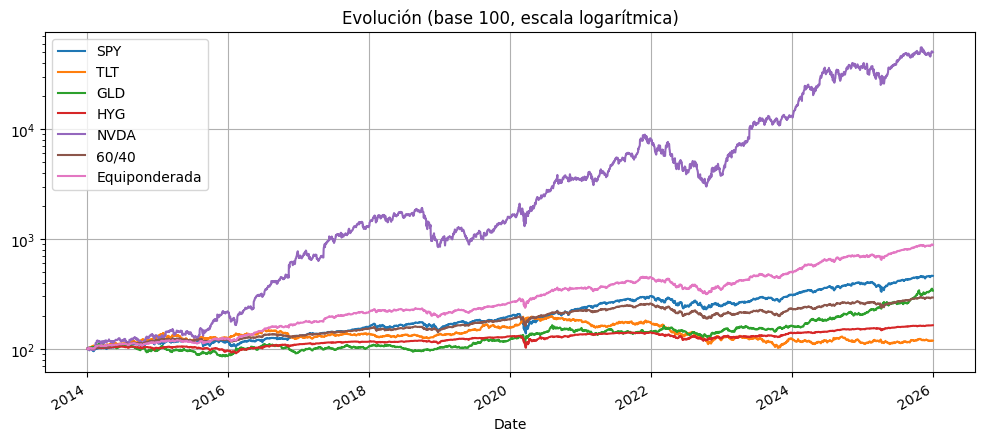

In [4]:
def constant_weight_nav(prices: pd.DataFrame, weights: dict[str, float]) -> pd.Series:
    """NAV (base 100) de una cartera con pesos constantes, rebalanceada cada periodo."""
    w = pd.Series(weights)
    components = prices[w.index].dropna()
    portfolio_returns = to_returns(components).dropna().dot(w)
    nav = 100 * (1 + portfolio_returns).cumprod()
    # El NAV empieza en 100 el primer día con precio de todos los componentes
    return pd.concat([pd.Series(100.0, index=components.index[:1]), nav])


portfolios = pd.DataFrame({
    "60/40": constant_weight_nav(assets, {"SPY": 0.6, "TLT": 0.4}),
    "Equiponderada": constant_weight_nav(assets, {t: 1 / len(TICKERS) for t in TICKERS}),
})

prices = assets.join(portfolios)

(prices / prices.bfill().iloc[0] * 100).plot(logy=True, title="Evolución (base 100, escala logarítmica)")
plt.show()

## 2. Tabla resumen

Todas las métricas del módulo, más la métrica propia. Convenciones:

* Rentabilidades, volatilidades y tracking error, **anualizados**.
* VaR y CVaR, **diarios** y como pérdida positiva.
* Tiempos (`Max Time Under Water`, `Recovery Time`) en **sesiones**.
* Tracking error frente a SPY.

In [5]:
summary = generate_risk_summary(prices, risk_free_rate=RF, benchmark_prices=prices["SPY"])

format_risk_summary(summary, transpose=True)

,SPY,TLT,GLD,HYG,NVDA,60/40,Equiponderada
CAGR,13.62%,1.46%,10.71%,4.22%,68.12%,9.40%,19.95%
Annualized Return,14.28%,2.54%,11.27%,4.47%,63.03%,9.58%,19.12%
Annualized Volatility,17.34%,14.73%,14.76%,8.10%,47.19%,10.91%,13.57%
Downside Deviation,12.32%,10.37%,10.18%,5.64%,30.43%,7.71%,9.02%
Sharpe Ratio,0.72,0.05,0.64,0.33,1.30,0.71,1.28
Sortino Ratio,1.01,0.07,0.93,0.47,2.01,1.00,1.91
Calmar Ratio,0.40,0.03,0.44,0.19,1.03,0.35,0.65
Maximum Drawdown,-33.72%,-48.35%,-24.49%,-22.03%,-66.34%,-27.24%,-30.79%
Max Time Under Water,488,1358,1327,550,373,663,382
Recovery Time,97,no recuperado,883,158,153,458,157


## 3. Gráficos

### 3.1 Drawdown

Caída respecto al máximo alcanzado hasta cada fecha (*underwater plot*). Muestra a la vez la profundidad y la duración de las pérdidas.

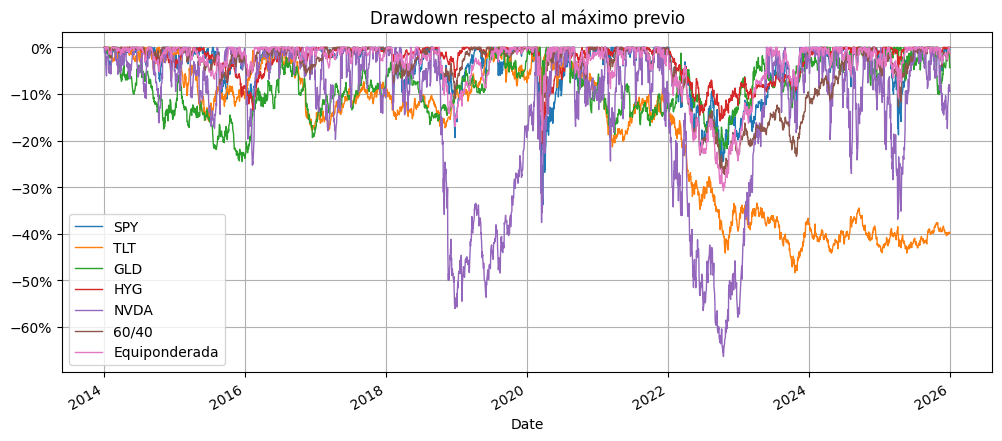

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
drawdown_series(prices).plot(ax=ax, lw=1)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("Drawdown respecto al máximo previo")
plt.show()

### 3.2 Volatilidad rolling (63 sesiones ≈ 3 meses, anualizada)

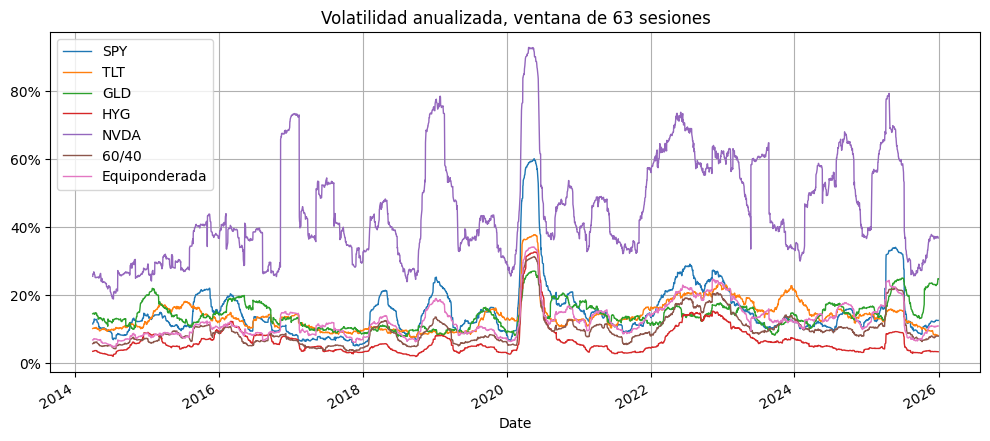

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
rolling_volatility(prices, window=63).plot(ax=ax, lw=1)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("Volatilidad anualizada, ventana de 63 sesiones")
plt.show()

### 3.3 Distribución de retornos diarios con VaR y CVaR al 95 %

Líneas: VaR histórico (naranja), CVaR histórico (rojo) y VaR gaussiano (azul discontinuo). Si el CVaR queda lejos del VaR, la cola es profunda: cuando se pierde más que el VaR, se pierde mucho más. El eje x se recorta al 99,9 % de los datos para que se vea la forma.

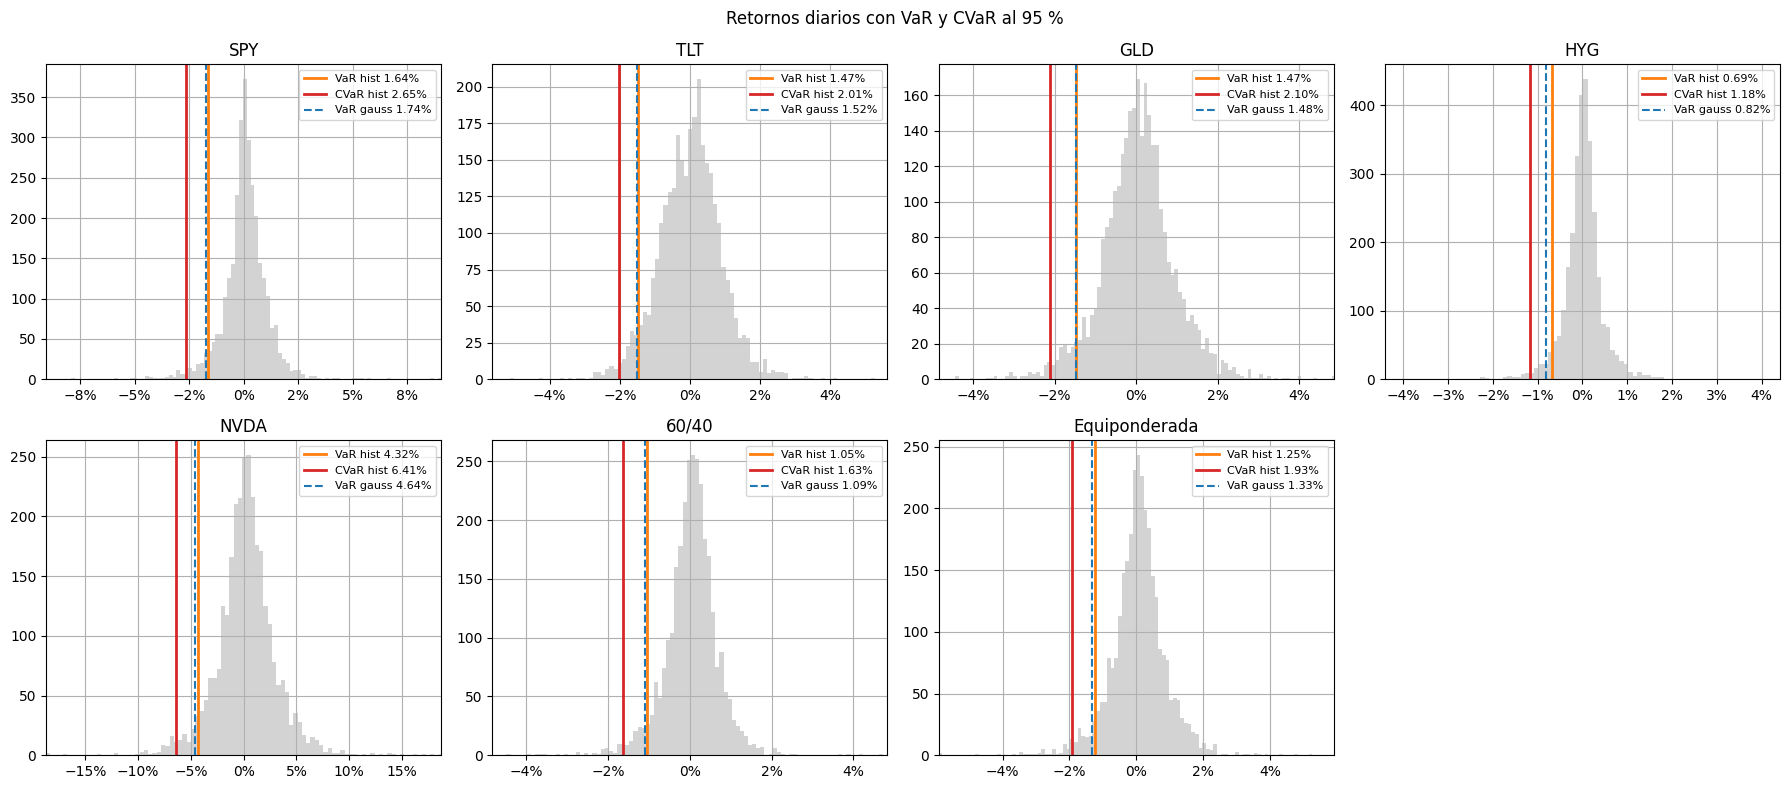

In [8]:
returns = to_returns(prices)
var95 = var_historical(prices, 0.95)
cvar95 = cvar_historical(prices, 0.95)
var95_gauss = var_parametric(prices, 0.95)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, name in zip(axes.flat, prices.columns):
    r = returns[name].dropna()
    ax.hist(r, bins=120, color="lightgray")
    ax.axvline(-var95[name], color="tab:orange", lw=2, label=f"VaR hist {var95[name]:.2%}")
    ax.axvline(-cvar95[name], color="tab:red", lw=2, label=f"CVaR hist {cvar95[name]:.2%}")
    ax.axvline(-var95_gauss[name], color="tab:blue", ls="--", label=f"VaR gauss {var95_gauss[name]:.2%}")
    lim = r.abs().quantile(0.999)
    ax.set_xlim(-lim, lim)
    ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
    ax.set_title(name)
    ax.legend(fontsize=8)

for ax in axes.flat[len(prices.columns):]:
    ax.axis("off")

fig.suptitle("Retornos diarios con VaR y CVaR al 95 %")
fig.tight_layout()
plt.show()

## 4. Preguntas

### 4.1 Nos dan 1 M€. ¿Nos convence alguna cartera? ¿Cuál y por qué?

Traducimos las métricas a euros sobre 1 M€ y ordenamos por *Tail-Adjusted Sharpe*, que penaliza tanto la volatilidad como la cola.

In [18]:
CAPITAL = 1_000_000

in_euros = pd.DataFrame({
    "CAGR": summary["CAGR"].map("{:.1%}".format),
    "Peor caída (€)": (summary["Maximum Drawdown"] * CAPITAL).map("{:,.0f}".format),
    "Pérdida media en el 5 % peor de días (€)": (-summary["CVaR 95% Historical"] * CAPITAL).map("{:,.0f}".format),
    "Sesiones sin recuperar máximo": summary["Max Time Under Water"],
    "Sharpe": summary["Sharpe Ratio"].round(2),
    "Tail-Adj. Sharpe": summary["Tail-Adjusted Sharpe"].round(2),
    "Calmar": summary["Calmar Ratio"].round(2),
}).loc[summary["Tail-Adjusted Sharpe"].sort_values(ascending=False).index]

in_euros

,CAGR,Peor caída (€),Pérdida media en el 5 % peor de días (€),Sesiones sin recuperar máximo,Sharpe,Tail-Adj. Sharpe,Calmar
NVDA,68.1%,"-663,351","-64,073",373,1.30,1.12,1.03
Equiponderada,20.0%,"-307,873","-19,269",382,1.28,1.04,0.65
60/40,9.4%,"-272,353","-16,350",663,0.71,0.55,0.35
GLD,10.7%,"-244,929","-21,041",1327,0.64,0.54,0.44
SPY,13.6%,"-337,173","-26,463",488,0.72,0.53,0.40
HYG,4.2%,"-220,287","-11,787",550,0.33,0.25,0.19
TLT,1.5%,"-483,512","-20,123",1358,0.05,0.05,0.03


In [19]:
# Robustez: ¿la equiponderada es buena por diversificar o solo por llevar NVDA?
ew_ex_nvda = constant_weight_nav(assets, {t: 0.25 for t in ["SPY", "TLT", "GLD", "HYG"]})

robustness = generate_risk_summary(
    pd.DataFrame({
        "Equiponderada": prices["Equiponderada"],
        "Equiponderada sin NVDA": ew_ex_nvda,
        "SPY": prices["SPY"],
    }),
    risk_free_rate=RF,
)

robustness[["CAGR", "Annualized Volatility", "Sharpe Ratio",
            "Tail-Adjusted Sharpe", "Maximum Drawdown"]].style.format({
    "CAGR": "{:.1%}", "Annualized Volatility": "{:.1%}", "Sharpe Ratio": "{:.2f}",
    "Tail-Adjusted Sharpe": "{:.2f}", "Maximum Drawdown": "{:.1%}",
})

,CAGR,Annualized Volatility,Sharpe Ratio,Tail-Adjusted Sharpe,Maximum Drawdown
Equiponderada,20.0%,13.6%,1.28,1.04,-30.8%
Equiponderada sin NVDA,8.1%,8.2%,0.77,0.62,-20.7%
SPY,13.6%,17.3%,0.72,0.53,-33.7%


**Respuesta:**

_(Completar tras ejecutar. Qué mirar: qué opción combina mejor rentabilidad y riesgo ajustado, si la peor caída en euros sería tolerable para quien pone el dinero, y cuánto tardaría en recuperarse. Comparar NVDA frente a las carteras: la rentabilidad pasada de un solo valor no es una estrategia replicable.)_

**Respuesta:**

**NVDA no nos convence**, aunque gane en todos los ratios (Sharpe 1,30, Calmar 1,03). Es un solo valor, lo elegimos sabiendo que fue el gran ganador de la década (sesgo retrospectivo) y su peor caída habría supuesto **−663.351 €** sobre 1 M€, con una pérdida media de **64.073 €** en el 5 % de peores días. Nadie aguanta eso sin vender en el peor momento.

**La Equiponderada es la mejor opción de la tabla**: segundo mejor Sharpe (1,28) y Tail-Adjusted Sharpe (1,04), CAGR del 20 % y una peor caída de −307.873 €, menor que la de SPY (−337.173 €).

Pero **su resultado depende de NVDA**. La misma cartera sin NVDA (25 % en SPY, TLT, GLD y HYG) da:

| | CAGR | Volatilidad | Sharpe | Tail-Adj. Sharpe | Max drawdown |
|---|---|---|---|---|---|
| Equiponderada | 20,0 % | 13,6 % | 1,28 | 1,04 | −30,8 % |
| Equiponderada sin NVDA | 8,1 % | 8,2 % | 0,77 | 0,62 | −20,7 % |
| SPY | 13,6 % | 17,3 % | 0,72 | 0,53 | −33,7 % |

Esto separa dos efectos:

* **La diversificación mejora el riesgo ajustado.** Incluso sin NVDA, la cartera supera a SPY en Sharpe y Tail-Adjusted Sharpe, y su peor caída es 13 puntos menor (−207.000 € frente a −337.000 €).
* **La rentabilidad alta viene de NVDA.** Sin ella, el CAGR baja al 8,1 %, 5,5 puntos por debajo de SPY.

**Nuestra decisión:** con la información disponible hoy, sin saber qué acción será la próxima NVDA, invertiríamos en una **cartera diversificada y rebalanceada**. Es la opción más robusta: gana a SPY en riesgo ajustado con o sin NVDA. Si el objetivo es maximizar el crecimiento del capital aceptando caídas de un tercio, SPY rinde más, pero con más riesgo por unidad de rentabilidad.

La **60/40 no convence en este periodo**: en 2022 bonos y acciones cayeron a la vez (−272.353 €), y TLT, su parte "defensiva", lleva 1.358 sesiones sin recuperar su máximo de 2020, con una caída máxima de −483.512 €, mayor que la de SPY.


### 4.2 ¿Qué activo tiene el peor perfil de cola y por qué no se aprecia mirando solo la volatilidad?

La volatilidad supone implícitamente una cola normal. Comparamos el VaR al 99 % que predice la normal con el observado, junto con la asimetría, la curtosis y el *Tail Excess Ratio* (τ) de la métrica propia.

In [10]:
tail_profile = pd.DataFrame({
    "Volatilidad": summary["Annualized Volatility"],
    "Asimetría": summary["Skewness"],
    "Exceso curtosis": summary["Excess Kurtosis"],
    "VaR 99% gaussiano": var_parametric(prices, 0.99),
    "VaR 99% histórico": var_historical(prices, 0.99),
    "VaR 99% Cornish-Fisher": var_parametric(prices, 0.99, distribution="cornish_fisher"),
    "Tail Excess Ratio (τ)": summary["Tail Excess Ratio"],
})
tail_profile["Histórico / gaussiano"] = tail_profile["VaR 99% histórico"] / tail_profile["VaR 99% gaussiano"]

tail_profile.sort_values("Tail Excess Ratio (τ)", ascending=False).style.format({
    "Volatilidad": "{:.1%}", "VaR 99% gaussiano": "{:.2%}", "VaR 99% histórico": "{:.2%}",
    "VaR 99% Cornish-Fisher": "{:.2%}", "Asimetría": "{:.2f}", "Exceso curtosis": "{:.1f}",
    "Tail Excess Ratio (τ)": "{:.2f}", "Histórico / gaussiano": "{:.2f}",
})

,Volatilidad,Asimetría,Exceso curtosis,VaR 99% gaussiano,VaR 99% histórico,VaR 99% Cornish-Fisher,Tail Excess Ratio (τ),Histórico / gaussiano
SPY,17.3%,-0.32,14.5,2.48%,3.04%,6.40%,1.35,1.22
HYG,8.1%,0.12,25.1,1.17%,1.35%,4.12%,1.32,1.15
60/40,10.9%,-0.23,10.0,1.56%,1.92%,3.27%,1.30,1.23
Equiponderada,13.6%,0.16,7.5,1.91%,2.16%,3.30%,1.23,1.13
GLD,14.8%,-0.14,3.1,2.12%,2.39%,2.88%,1.19,1.13
NVDA,47.2%,0.58,8.8,6.67%,7.35%,11.12%,1.16,1.10
TLT,14.7%,0.07,4.5,2.15%,2.26%,3.08%,1.11,1.05


In [11]:
rank_compare = pd.DataFrame({
    "Rank por volatilidad": summary["Annualized Volatility"].rank(ascending=False),
    "Rank por τ (forma de la cola)": summary["Tail Excess Ratio"].rank(ascending=False),
}).astype(int).sort_values("Rank por τ (forma de la cola)")

rank_compare

,Rank por volatilidad,Rank por τ (forma de la cola)
SPY,2,1
HYG,7,2
60/40,6,3
Equiponderada,5,4
GLD,3,5
NVDA,1,6
TLT,4,7


**Respuesta:**

_(Completar. Qué mirar: el activo con mayor τ, exceso de curtosis y cociente histórico/gaussiano; si está abajo en volatilidad y arriba en τ, esa es la respuesta a "por qué no se aprecia con la volatilidad". HYG es el candidato esperado: pocas oscilaciones en condiciones normales y caídas bruscas en crisis de crédito, como marzo de 2020.)_

**Respuesta:**

En términos absolutos, NVDA tiene la cola más grande (VaR 99 % histórico del 7,35 % diario), pero eso ya se ve en su volatilidad del 47 %. El activo cuya cola **no se aprecia mirando la volatilidad es HYG**:

* Es el **menos volátil** (8,1 %, puesto 7 de 7) y, sin embargo, el **segundo en forma de cola** (τ = 1,32) y el de **mayor exceso de curtosis** (25,1).
* Su CVaR histórico al 95 % supera al gaussiano (1,18 % frente a 1,04 %), aunque su VaR histórico al 95 % sea menor (0,69 % frente a 0,82 %). La mayoría de días es más tranquilo de lo que predice la normal, pero cuando cae, cae más.
* El motivo es económico: el high yield se comporta como renta fija en condiciones normales y como renta variable en crisis de crédito (marzo de 2020).

Otro hallazgo: **la 60/40 tiene el mayor cociente VaR 99 % histórico / gaussiano (1,23)**. Diversificar reduce la volatilidad (10,9 %), pero no la cola: en las crisis las correlaciones suben y la diversificación desaparece justo cuando hace falta.

El ranking por volatilidad y el ranking por forma de cola son casi opuestos. NVDA es la más volátil y la sexta en cola; HYG, la menos volátil y la segunda en cola.

Dos advertencias metodológicas:

* **La asimetría no sirve aquí**: HYG sale con +0,12 porque los rebotes de 2020 compensan las caídas. Con curtosis tan altas, unos pocos días dominan el tercer momento.
* **Cornish-Fisher no es fiable con estas curtosis**: al 95 % da menos VaR que la normal, y al 99 % triplica el histórico en HYG (4,12 % frente a 1,35 %). La expansión solo es válida para desviaciones moderadas de la normalidad.

### 4.3 ¿Coincide el ranking por Sharpe con el ranking por Calmar?

Sharpe mide el riesgo con toda la dispersión; Calmar, con el peor episodio. Se comparan los rankings y su correlación de Spearman (1 = mismo orden).

In [12]:
rankings = pd.DataFrame({
    "Sharpe": summary["Sharpe Ratio"],
    "Rank Sharpe": summary["Sharpe Ratio"].rank(ascending=False).astype(int),
    "Calmar": summary["Calmar Ratio"],
    "Rank Calmar": summary["Calmar Ratio"].rank(ascending=False).astype(int),
    "Max drawdown": summary["Maximum Drawdown"],
}).sort_values("Rank Sharpe")

spearman = summary["Sharpe Ratio"].corr(summary["Calmar Ratio"], method="spearman")
print(f"Correlación de Spearman entre rankings: {spearman:.2f}")

rankings.style.format({"Sharpe": "{:.2f}", "Calmar": "{:.2f}", "Max drawdown": "{:.1%}"})

Correlación de Spearman entre rankings: 0.89


,Sharpe,Rank Sharpe,Calmar,Rank Calmar,Max drawdown
NVDA,1.30,1,1.03,1,-66.3%
Equiponderada,1.28,2,0.65,2,-30.8%
SPY,0.72,3,0.40,4,-33.7%
60/40,0.71,4,0.35,5,-27.2%
GLD,0.64,5,0.44,3,-24.5%
HYG,0.33,6,0.19,6,-22.0%
TLT,0.05,7,0.03,7,-48.4%


**Respuesta:**

_(Completar. Qué mirar: qué activos cambian de posición y por qué. Un activo con volatilidad moderada pero un único drawdown profundo, como TLT en 2022, sube en Sharpe y baja en Calmar. Calmar depende de un solo episodio, así que es más inestable ante la ventana elegida.)_

**Respuesta:**

**Casi coinciden** (correlación de Spearman de 0,89). NVDA y la Equiponderada son primera y segunda en ambos rankings, y HYG y TLT, las dos últimas. Cambia la zona media:

| | Rank Sharpe | Rank Calmar | Max drawdown |
|---|---|---|---|
| GLD | 5 | **3** | −24,5 % |
| SPY | 3 | 4 | −33,7 % |
| 60/40 | 4 | 5 | −27,2 % |

* **GLD sube** porque su peor caída es moderada en relación con lo que rinde.
* **SPY y 60/40 bajan** porque su drawdown máximo (2020 y 2022) pesa más de lo que sugiere su volatilidad media.

Las diferencias vienen de cómo mide el riesgo cada ratio. Sharpe usa toda la dispersión, incluidas las subidas; Calmar, **un único episodio**, el peor. Por eso Calmar es más sensible a la ventana elegida: otro periodo con otra crisis podría reordenar el ranking. Además, Calmar usa el CAGR y no descuenta el tipo libre de riesgo.

### 4.4 ¿Cómo se comporta el VaR paramétrico en dos periodos diferentes?

El VaR gaussiano depende solo de la media y la volatilidad de la ventana en la que se estima. Se compara:

* **Periodo tranquilo:** estimado con 2019 y aplicado a 2020 (COVID).
* **Periodo estresado:** estimado con 2020 y aplicado a 2021.

Si el VaR al 95 % fuera correcto, se superaría en torno al **5 %** de los días del año siguiente.

In [13]:
def var_backtest(prices, estimation, test, confidence=0.95):
    """VaR gaussiano estimado en una ventana y % de días que lo superan en la siguiente."""
    var = var_parametric(prices.loc[estimation[0]:estimation[1]], confidence)
    test_returns = to_returns(prices.loc[test[0]:test[1]]).dropna(how="all")
    exceedances = test_returns.lt(-var).sum() / test_returns.count()
    return var, exceedances


var_2019, exc_2020 = var_backtest(assets, ("2019-01-01", "2019-12-31"), ("2020-01-01", "2020-12-31"))
var_2020, exc_2021 = var_backtest(assets, ("2020-01-01", "2020-12-31"), ("2021-01-01", "2021-12-31"))

pd.DataFrame({
    "VaR 95% estimado en 2019": var_2019,
    "% días que lo superan en 2020": exc_2020,
    "VaR 95% estimado en 2020": var_2020,
    "% días que lo superan en 2021": exc_2021,
}).style.format("{:.2%}")

,VaR 95% estimado en 2019,% días que lo superan en 2020,VaR 95% estimado en 2020,% días que lo superan en 2021
SPY,1.19%,15.08%,3.38%,0.00%
TLT,1.18%,9.52%,2.16%,0.40%
GLD,1.14%,12.70%,1.93%,3.59%
HYG,0.42%,17.86%,1.78%,0.00%
NVDA,3.96%,8.73%,5.62%,1.99%


Visualmente, para SPY: VaR gaussiano rolling (ventana de 1 año) frente a los retornos del día siguiente. Los puntos rojos son los días que lo superan.

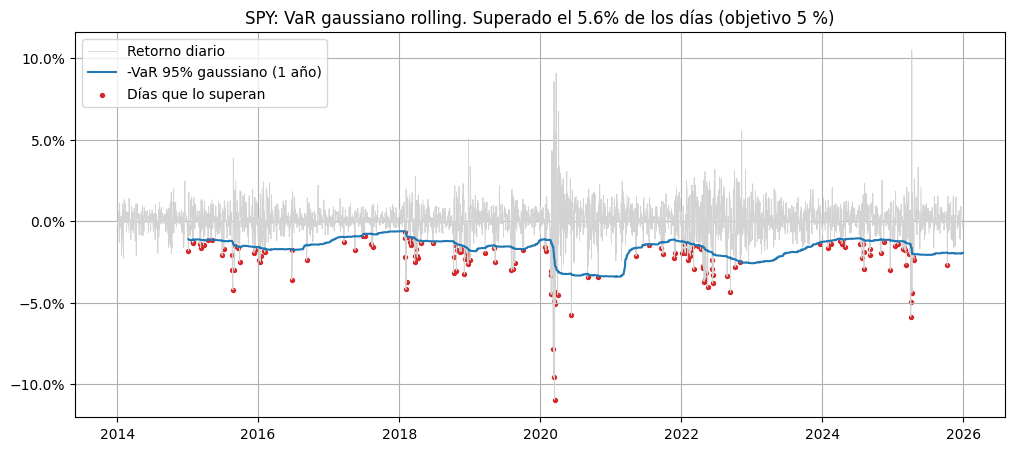

In [14]:
spy = returns["SPY"].dropna()
window = 252
z = norm.ppf(0.05)
rolling_var = -(spy.rolling(window).mean() + z * spy.rolling(window).std()).shift(1)
breaches = spy < -rolling_var

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(spy.index, spy, color="lightgray", lw=0.6, label="Retorno diario")
ax.plot(rolling_var.index, -rolling_var, color="tab:blue", lw=1.5, label="-VaR 95% gaussiano (1 año)")
ax.scatter(spy.index[breaches], spy[breaches], color="tab:red", s=8, label="Días que lo superan")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title(f"SPY: VaR gaussiano rolling. Superado el {breaches[rolling_var.notna()].mean():.1%} de los días (objetivo 5 %)")
ax.legend()
plt.show()

**Respuesta:**

_(Completar. Qué mirar: estimado en un año tranquilo, el VaR es bajo y en el año siguiente de crisis se supera muchas más veces del 5 %. Estimado en un año de crisis, es alto y en el año siguiente se supera menos del 5 %. El VaR paramétrico reacciona con retraso: infravalora el riesgo justo antes de las crisis y lo sobrevalora después.)_

**Respuesta:**

**El VaR paramétrico reacciona con retraso**: infravalora el riesgo justo antes de una crisis y lo sobrevalora después.

* **Estimado en 2019 (año tranquilo) y aplicado a 2020:** se supera entre el 8,7 % (NVDA) y el **17,9 % (HYG)** de los días, cuando debería ser el 5 %. El caso de HYG es el más grave: un VaR del 0,42 % estimado con un año sin sobresaltos se supera 3,6 veces más de lo previsto.
* **Estimado en 2020 (COVID) y aplicado a 2021:** se supera el **0 %** de los días en SPY y HYG, y el 0,4 % en TLT. Tras la crisis, el VaR queda inflado y sobrestima el riesgo.

El gráfico de SPY con VaR rolling de un año lo muestra en toda la muestra:

* **En media parece bien calibrado** (se supera el 5,6 % de los días, cerca del 5 %).
* **Pero los excesos se concentran** en 2020, 2022 y abril de 2025. Un VaR correcto tendría excesos repartidos al azar. Que se agrupen indica que no capta la **agrupación de la volatilidad** (*volatility clustering*): los días malos vienen seguidos.
* **Se ve el efecto fantasma**: tras marzo de 2020, el VaR se mantiene alto un año entero sin ningún exceso y cae de golpe a principios de 2021, cuando la crisis sale de la ventana. El riesgo no cambió ese día; cambió la muestra.

Pasar la prueba "en media" no basta: un modelo de riesgo tiene que acertar cuándo, no solo cuántas veces. Alternativas que corrigen esto: una volatilidad con más peso a los datos recientes (EWMA o GARCH) o el VaR histórico filtrado.

### 4.5 ¿Qué nos dice la métrica propia?

**Volatilidad ajustada por cola (TAV):** $\text{TAV} = \sigma \cdot \max(1, \tau)$, con $\tau$ = CVaR histórico / CVaR gaussiano (al 97,5 %, sobre retornos centrados). Documentación completa en `quantmgmt/risk/custom.py`.

Si τ ≈ 1, la volatilidad cuenta toda la historia. Si τ > 1, hay riesgo de cola que la volatilidad esconde. El *Tail-Adjusted Sharpe* sustituye σ por la TAV en el denominador.

In [15]:
own_metric = pd.DataFrame({
    "Volatilidad": summary["Annualized Volatility"],
    "τ": summary["Tail Excess Ratio"],
    "TAV": summary["Tail-Adjusted Volatility"],
    "Penalización": summary["Tail-Adjusted Volatility"] / summary["Annualized Volatility"] - 1,
    "Sharpe": summary["Sharpe Ratio"],
    "Tail-Adj. Sharpe": summary["Tail-Adjusted Sharpe"],
    "Rank Sharpe": summary["Sharpe Ratio"].rank(ascending=False).astype(int),
    "Rank Tail-Adj. Sharpe": summary["Tail-Adjusted Sharpe"].rank(ascending=False).astype(int),
}).sort_values("τ", ascending=False)

own_metric.style.format({
    "Volatilidad": "{:.1%}", "τ": "{:.2f}", "TAV": "{:.1%}", "Penalización": "{:+.1%}",
    "Sharpe": "{:.2f}", "Tail-Adj. Sharpe": "{:.2f}",
})

,Volatilidad,τ,TAV,Penalización,Sharpe,Tail-Adj. Sharpe,Rank Sharpe,Rank Tail-Adj. Sharpe
SPY,17.3%,1.35,23.4%,+35.2%,0.72,0.53,3,5
HYG,8.1%,1.32,10.7%,+32.0%,0.33,0.25,6,6
60/40,10.9%,1.30,14.2%,+30.5%,0.71,0.55,4,3
Equiponderada,13.6%,1.23,16.7%,+22.8%,1.28,1.04,2,2
GLD,14.8%,1.19,17.5%,+18.7%,0.64,0.54,5,4
NVDA,47.2%,1.16,54.9%,+16.3%,1.30,1.12,1,1
TLT,14.7%,1.11,16.3%,+10.9%,0.05,0.05,7,7


**Respuesta:**

_(Completar. Qué mirar: qué activos reciben más penalización, si coincide con el peor perfil de cola de 4.2, y si algún activo cambia de posición al pasar de Sharpe a Tail-Adjusted Sharpe. Si nadie cambia de posición, también es un resultado: el ranking por Sharpe es robusto para estos activos.)_

**Respuesta:**

La TAV cuantifica **cuánto riesgo esconde la volatilidad** en cada activo. La penalización va del +10,9 % (TLT) al +35,2 % (SPY):

* **Más penalizados:** SPY (τ = 1,35), HYG (1,32) y 60/40 (1,30). Son los activos expuestos a crisis bruscas (marzo de 2020, abril de 2025), en las que las caídas superan lo que predice su volatilidad. Coincide con lo visto en 4.2.
* **Menos penalizados:** TLT (1,11) y NVDA (1,16). Su riesgo ya está en la volatilidad: TLT cae de forma gradual (subida de tipos en 2022) y NVDA es muy volátil todos los días, no solo en las crisis.

El ranking **cambia en la zona media** al pasar de Sharpe a Tail-Adjusted Sharpe:

* **SPY baja del 3.º al 5.º puesto**: su Sharpe (0,72) sobrestima su calidad, porque parte de su riesgo está en la cola.
* **60/40 y GLD suben** un puesto cada uno.
* Arriba (NVDA, Equiponderada) y abajo (HYG, TLT) el orden se mantiene.

Conclusión: la métrica no sustituye al resto, pero añade información que ni la volatilidad ni el VaR dan por separado. Dos activos con el mismo Sharpe pueden tener riesgos muy distintos, y la TAV lo detecta en las mismas unidades que la volatilidad, así que se puede usar directamente para comparar o, en la P2, para optimizar carteras.

## 5. Conclusiones

1. **La volatilidad no basta para medir el riesgo.** Los activos menos volátiles (HYG) o más diversificados (60/40) son los que más riesgo de cola esconden en relación con su volatilidad. La TAV lo cuantifica: hasta un +35 % de riesgo adicional sobre σ.
2. **Diversificar reduce la volatilidad, pero no protege en las crisis.** La 60/40 tiene la cola relativa más gorda al 99 %, y en 2022 bonos y acciones cayeron juntos. TLT, el activo "seguro", sufrió una caída mayor que la de SPY y sigue sin recuperarse.
3. **Los modelos paramétricos fallan cuando más importa.** El VaR gaussiano parece calibrado en media, pero concentra los errores en las crisis. Cornish-Fisher tampoco lo resuelve con curtosis tan altas.
4. **Los rankings dependen de la métrica.** Sharpe, Calmar y Tail-Adjusted Sharpe coinciden en los extremos, pero reordenan la zona media. Para decidir una inversión conviene mirar varias a la vez y traducirlas a euros, que es lo que de verdad pierde el inversor.